# CubeML: voorspellen van de volgende Rubik's cube move

Deze notebook bundelt de volledige projectflow in een vorm die makkelijk te reviewen is: dataset laden, preprocessing controleren, enkele visualisaties maken, een model trainen en de voorspellingen evalueren.

Logische flow:

1. Projectpaden, imports en dataset-loader instellen.
2. De verwerkte dataset `dataset_no_prime.pkl` rechtstreeks laden vanuit de projectomgeving. In deze variant wordt de target teruggebracht naar 6 basiszetten (`B`, `D`, `F`, `L`, `R`, `U`).
3. Controleren hoeveel features, samples en move-klassen er zijn, en hoe scheef de klassedistributie is.
4. Een stratified train/test split maken en een Random Forest trainen als interpreteerbare baseline.
5. Evalueren met accuracy, balanced accuracy, macro F1, ROC-AUC, confusion matrix en feature importance.
6. Optioneel een korte solve-loop demonstreren met het getrainde model.

In [7]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "CubeML" / "datasets").exists():
            return candidate
    raise FileNotFoundError("Could not find the CubeML project root from the current notebook directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RANDOM_STATE = 42
PROCESSED_DATA_DIR = PROJECT_ROOT / "CubeML" / "datasets" / "cfop-dataset-processed"
DATASET_PATH = PROCESSED_DATA_DIR / "dataset_no_prime.pkl"

# Runtime-safe defaults for review. Increase or set to None for a full final run.
DATASET_MAX_ROWS = 60000
MODEL_MAX_ROWS = 25000

df = pd.read_pickle(DATASET_PATH).drop_duplicates().reset_index(drop=True)
feature_columns = [column for column in df.columns if column.startswith("TILE_")]
df[feature_columns] = df[feature_columns].astype("int8")
df["MOVE"] = df["MOVE"].astype(str)

if DATASET_MAX_ROWS is not None and len(df) > DATASET_MAX_ROWS:
    df = df.sample(n=DATASET_MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Loaded {len(df):,} rows from processed dataset: {DATASET_PATH.name}.")
print(f"Feature columns: {len(feature_columns)}")
print(f"Move classes: {sorted(df['MOVE'].unique())}")
df.head()

Loaded 60,000 rows from processed dataset: dataset_no_prime.pkl.
Feature columns: 48
Move classes: ['B', 'D', 'F', 'L', 'R', 'U']


,TILE_L1,TILE_L2,TILE_L3,TILE_L4,TILE_L6,TILE_L7,TILE_L8,TILE_L9,TILE_U1,TILE_U2,...,TILE_R9,TILE_B1,TILE_B2,TILE_B3,TILE_B4,TILE_B6,TILE_B7,TILE_B8,TILE_B9,MOVE
0,0,0,0,0,1,4,5,3,5,2,...,4,4,0,3,5,3,5,5,1,L
1,0,1,1,0,2,0,4,1,5,2,...,2,4,1,3,3,3,4,1,3,B
2,0,1,3,0,1,2,0,2,3,1,...,4,0,2,2,5,3,5,5,1,U
3,3,5,0,3,2,4,0,4,4,1,...,0,3,0,2,3,5,5,1,5,R
4,3,5,0,5,5,0,0,4,0,2,...,5,1,4,5,0,0,4,5,1,R


## Datasetcontrole en visualisaties

De ruwe cube state bevat 54 stickers. De zes middelste stickers bewegen nooit, dus de features bestaan uit de overige 48 tegelposities. In deze notebook gebruiken we de `no_prime`-variant van de dataset: de target bevat daardoor nog 6 move-klassen, maar de verdeling blijft duidelijk scheef, met `U` als grootste klasse.

,waarde
samples,60000.000000
features,48.000000
move classes,6.000000
majority-class baseline,0.364767


,aantal
MOVE,
U,21886
F,9484
B,9089
R,8486
L,7879
D,3176


,mutual information
TILE_D6,0.168041
TILE_R8,0.163629
TILE_D2,0.158213
TILE_B8,0.157947
TILE_D8,0.152076
TILE_F8,0.150127
TILE_R4,0.145998
TILE_F6,0.140325
TILE_D3,0.134153
TILE_B4,0.131646


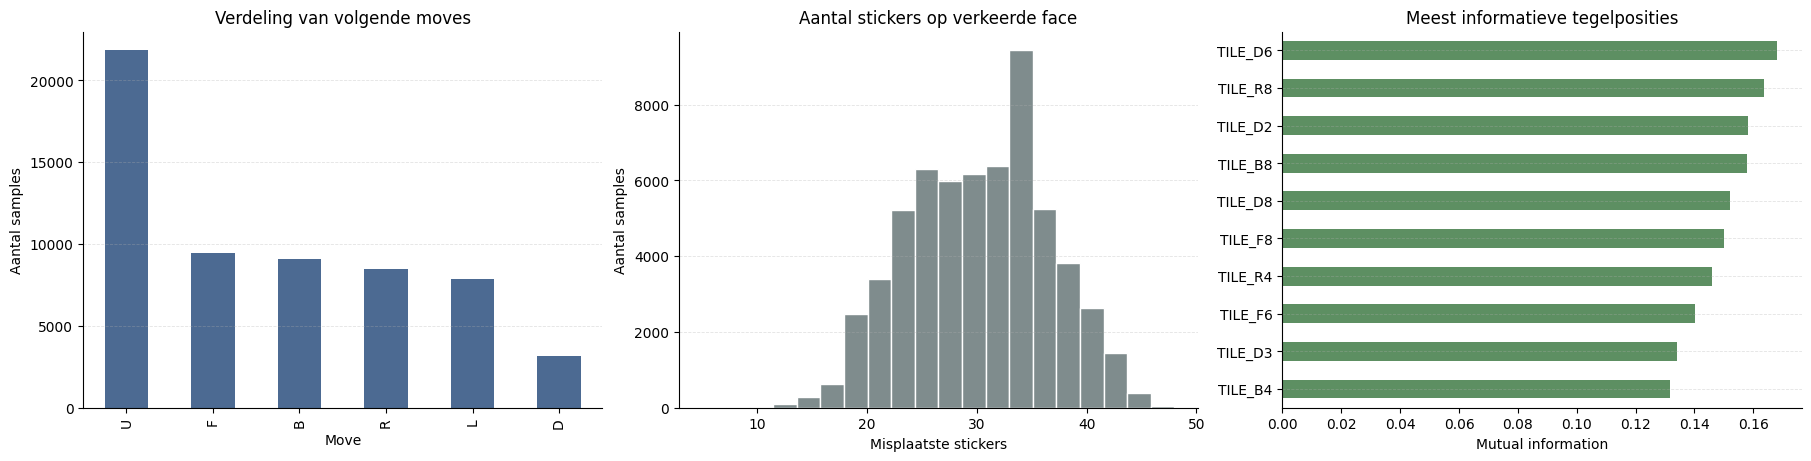

In [8]:
from sklearn.feature_selection import mutual_info_classif

feature_columns = [column for column in df.columns if column.startswith("TILE_")]
move_counts = df["MOVE"].value_counts().sort_values(ascending=False)

summary = pd.DataFrame(
    {
        "waarde": [
            len(df),
            len(feature_columns),
            df["MOVE"].nunique(),
            move_counts.iloc[0] / len(df),
        ]
    },
    index=["samples", "features", "move classes", "majority-class baseline"],
)
display(summary)
display(move_counts.rename("aantal").to_frame())

expected_face_color = {"L": 0, "U": 1, "F": 2, "D": 3, "R": 4, "B": 5}
expected_values = pd.Series(
    {
        column: expected_face_color[column[5]]
        for column in feature_columns
    }
)
misplaced_stickers = df[feature_columns].ne(expected_values, axis="columns").sum(axis=1)

mutual_information = pd.Series(
    mutual_info_classif(
        df[feature_columns],
        df["MOVE"],
        discrete_features=True,
        random_state=RANDOM_STATE,
    ),
    index=feature_columns,
).sort_values(ascending=False)

display(mutual_information.head(10).rename("mutual information").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)
move_counts.plot(kind="bar", ax=axes[0], color="#4c6a92")
axes[0].set_title("Verdeling van volgende moves")
axes[0].set_xlabel("Move")
axes[0].set_ylabel("Aantal samples")

axes[1].hist(misplaced_stickers, bins=20, color="#7f8c8d", edgecolor="white")
axes[1].set_title("Aantal stickers op verkeerde face")
axes[1].set_xlabel("Misplaatste stickers")
axes[1].set_ylabel("Aantal samples")

mutual_information.head(10).sort_values().plot(kind="barh", ax=axes[2], color="#5d8f62")
axes[2].set_title("Meest informatieve tegelposities")
axes[2].set_xlabel("Mutual information")

for axis in axes:
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

plt.show()

### Tussentijdse conclusie: dataset

De vereenvoudiging naar de `no_prime`-dataset maakt het classificatieprobleem overzichtelijker, maar niet triviaal. We houden nog steeds 48 featureposities over en de klassenverdeling blijft duidelijk onevenwichtig: `U` domineert de dataset, terwijl `D` veel minder vaak voorkomt. Daardoor is een majority-baseline al verrassend sterk en moeten we naast accuracy ook naar meer gebalanceerde maten kijken.

## Modeltraining en evaluatie

We gebruiken een stratified train/test split zodat elke move-klasse ongeveer evenredig terugkomt in train en test. Het model hieronder is een Random Forest: sterk genoeg als baseline, sneller dan de volledige MLP/random-search flow, en goed uitlegbaar via feature importance. Op de `no_prime`-dataset is het classificatieprobleem eenvoudiger dan bij 18 klassen, maar de klassedistributie blijft onevenwichtig, waardoor accuracy alleen niet volstaat en macro-metrics belangrijk blijven.

,score
majority baseline accuracy,0.368200
accuracy,0.713200
balanced accuracy,0.685491
macro F1,0.694534
macro ROC-AUC OvR,0.941922


              precision    recall  f1-score   support

           B       0.78      0.68      0.73       748
           D       0.56      0.59      0.58       254
           F       0.75      0.60      0.67       795
           L       0.83      0.74      0.78       654
           R       0.65      0.72      0.68       708
           U       0.69      0.78      0.73      1841

    accuracy                           0.71      5000
   macro avg       0.71      0.69      0.69      5000
weighted avg       0.72      0.71      0.71      5000



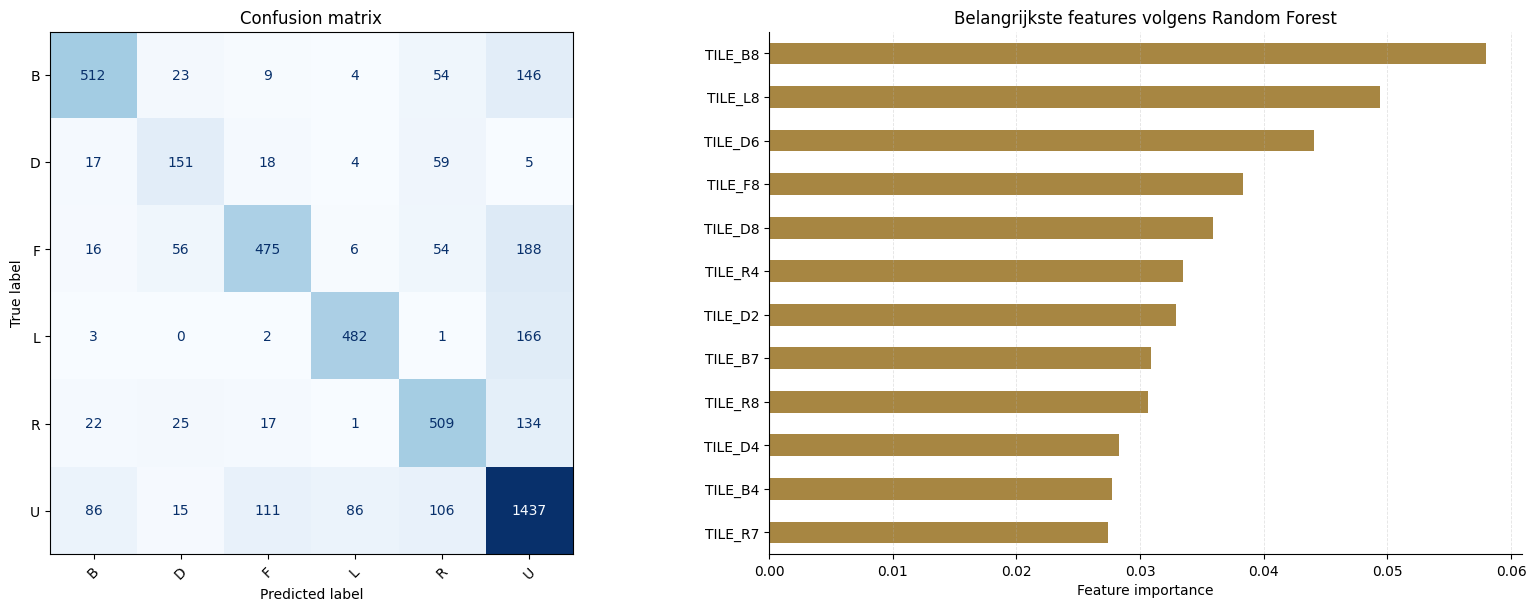

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

model_df = df.copy()

if MODEL_MAX_ROWS is not None and len(model_df) > MODEL_MAX_ROWS:
    model_df = model_df.sample(n=MODEL_MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)

class_counts = model_df["MOVE"].value_counts()
usable_classes = class_counts[class_counts >= 2].index
model_df = model_df[model_df["MOVE"].isin(usable_classes)].reset_index(drop=True)

X = model_df[feature_columns]
y = model_df["MOVE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

majority_baseline = y_test.value_counts(normalize=True).iloc[0]

model = RandomForestClassifier(
    n_estimators=80,
    max_depth=24,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

try:
    macro_roc_auc = roc_auc_score(
        y_test,
        probabilities,
        labels=model.classes_,
        multi_class="ovr",
        average="macro",
    )
except ValueError:
    macro_roc_auc = np.nan

metrics = pd.DataFrame(
    {
        "score": {
            "majority baseline accuracy": majority_baseline,
            "accuracy": accuracy_score(y_test, predictions),
            "balanced accuracy": balanced_accuracy_score(y_test, predictions),
            "macro F1": f1_score(y_test, predictions, average="macro"),
            "macro ROC-AUC OvR": macro_roc_auc,
        }
    }
)
display(metrics)

print(classification_report(y_test, predictions, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    labels=model.classes_,
    xticks_rotation=45,
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Confusion matrix")

feature_importance = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
feature_importance.head(12).sort_values().plot(kind="barh", ax=axes[1], color="#a78642")
axes[1].set_title("Belangrijkste features volgens Random Forest")
axes[1].set_xlabel("Feature importance")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(axis="x", linestyle="--", linewidth=0.6, alpha=0.35)

plt.show()

### Tussentijdse conclusie: modelscore

De Random Forest scoort duidelijk beter dan de majority-baseline en houdt ook onder macro-metrics stand. Dat is belangrijk, omdat de klassenverdeling scheef is: een hoge accuracy alleen zou anders vooral kunnen betekenen dat het model te vaak `U` voorspelt. De ROC-curves hieronder maken zichtbaar hoe goed de kansen per klasse gescheiden worden, niet alleen welke klasse uiteindelijk als winnaar uit de bus komt.

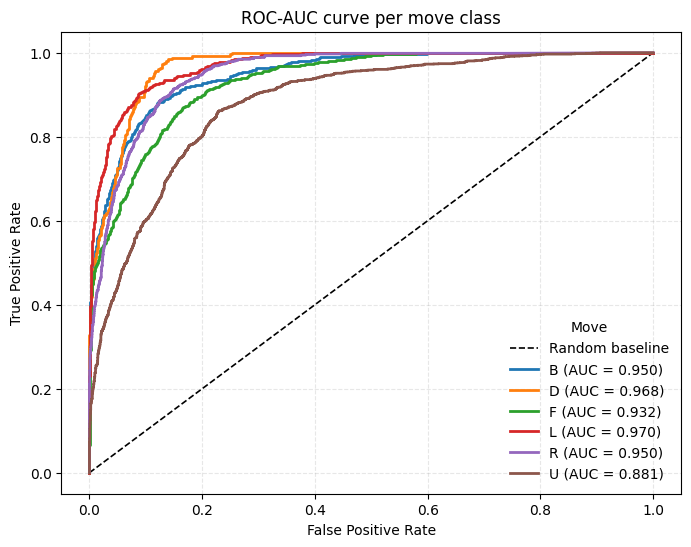

In [12]:
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize

y_test_binary = label_binarize(y_test, classes=model.classes_)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.2, label="Random baseline")

for class_index, class_name in enumerate(model.classes_):
    fpr, tpr, _ = roc_curve(y_test_binary[:, class_index], probabilities[:, class_index])
    class_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{class_name} (AUC = {class_auc:.3f})")

plt.title("ROC-AUC curve per move class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(title="Move", frameon=False)
plt.grid(alpha=0.3, linestyle="--")
plt.show()

### Tussentijdse conclusie: ROC-AUC

De ROC-curves tonen dat het model voor de meeste klassen een sterke scheiding leert tussen de juiste en foutieve voorspellingen. Vooral `D` en `L` hebben zeer hoge AUC-waarden, terwijl `U` merkbaar lager ligt. Dat past bij de eerdere observatie dat `U` wel vaak voorkomt, maar daardoor ook de klasse is waarin de beslissingsgrens het minst scherp blijft.

## Simulatie met het getrainde model

Deze laatste codecel gebruikt het model iteratief: voorspel een move, voer die move uit op de cube state, en herhaal tot de kubus opgelost is of tot een maximum aantal stappen bereikt wordt. Dit is strenger dan losse classificatie-accuracy, omdat fouten zich kunnen opstapelen. Bij de huidige no-prime run zien we meteen waarom deze stap belangrijk blijft: een degelijk classificatieresultaat betekent nog niet dat het model een stabiel oplossingspad vindt.

In [10]:
MAX_DEMO_MOVES = 40

try:
    from CubeML.utils.cube import execute_move, is_cube_solved, visualize_scramble_terminal
except ModuleNotFoundError as exc:
    print(f"Cube simulation skipped: missing dependency {exc.name!r}.")
    print("Install the project dependencies from pyproject.toml to run this optional demo.")
else:
    state = X_test.iloc[[0]].copy()
    predicted_moves: list[str] = []

    for _ in range(MAX_DEMO_MOVES):
        if is_cube_solved(state):
            break

        move = str(model.predict(state[feature_columns])[0])
        predicted_moves.append(move)
        state = execute_move(move, state)

    print(f"Predicted moves ({len(predicted_moves)}): {' '.join(predicted_moves)}")
    print(f"Solved within {MAX_DEMO_MOVES} moves: {is_cube_solved(state)}")
    visualize_scramble_terminal(state)

Predicted moves (40): U U U R U L L L L L L L L L L L L L L L L L L L L L L L L L L L L L L L L L L L
Solved within 40 moves: False
         [w][o][y]
         [b][y][y]
         [g][r][b]
[r][r][o][y][g][y][o][b][b][r][y][g]
[r][r][r][w][g][g][o][o][o][b][b][y]
[w][g][y][g][g][g][o][o][o][b][b][r]
         [r][w][w]
         [y][w][w]
         [b][w][w]



### Tussentijdse conclusie: simulatie

De simulatie maakt het verschil duidelijk tussen een goede kansverdeling per stap en een volledige oplossingsstrategie. Hoewel de classifier sterk scoort op testdata, stapelen lokale fouten zich in de roll-out op. Daardoor blijft het model hangen in herhaalde zetten en geraakt de kubus niet opgelost binnen de ingestelde limiet.

## Conclusie

De notebook laat het volledige machine-learning traject zien: de CFOP states worden omgezet naar 48 beweeglijke sticker-features, de volgende move is de target, en een Random Forest wordt geëvalueerd als multiclass classifier.

Voor de huidige `dataset_no_prime.pkl` run leverde dat het volgende beeld op:

- De target bevat 6 basiszetten in plaats van 18 klassen, maar de data blijft scheef verdeeld. `U` is veruit de grootste klasse en zet de majority baseline al op ongeveer 36.8%.
- De Random Forest presteert daar duidelijk boven met ongeveer 71.3% accuracy, 68.5% balanced accuracy, 69.5% macro F1 en 0.942 macro ROC-AUC op de huidige sample.
- De ROC-curves tonen dat de meeste klassen sterk gescheiden worden. `D` en `L` scoren het hoogst, terwijl `U` de zwakste AUC heeft en dus ook probabilistisch de moeilijkste klasse blijft.
- Die verbetering op single-step classificatie vertaalt zich nog niet naar een volledige solve. In de simulatie bleef het model hangen in een lange reeks `L`-voorspellingen en werd de kubus niet opgelost binnen 40 zetten.
- De notebook gaat rechtstreeks uit van de verwerkte `dataset_no_prime.pkl` in de project-venv.
- De notebook gebruikt standaard kleinere samples voor een snelle review. Voor een volledige run kunnen `DATASET_MAX_ROWS` en `MODEL_MAX_ROWS` bovenaan verhoogd worden of op `None` gezet worden.